**Import các thư viện cần thiết**

In [2]:
# Thu viện phân tích dữ liệu và về biểu đồ thông thường
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Tải dữ liệu từ file .csv**


In [3]:
df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


**Xem thông tin của dataframe**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


**Số lượng mẫu trong cột "target" của DataFrame df theo từng giá trị**

In [ ]:
df['target'].value_counts()

,count
target,
1,526
0,499


**Vẽ biểu đồ cột của số lượng mẫu trong cột 'target' của DataFrame df theo từng giá trị**

Text(0.5, 1.0, 'Heart Disease Count')

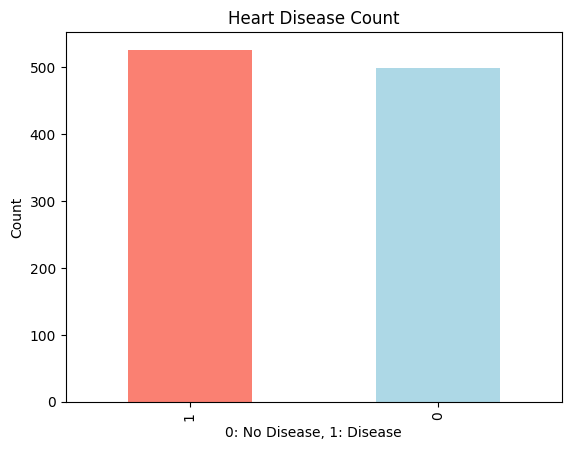

In [ ]:
df['target'].value_counts().plot.bar(color=['salmon', 'lightblue'])
plt.xlabel('0: No Disease, 1: Disease')
plt.ylabel('Count')
plt.title('Heart Disease Count')

**So sánh khả năng mắc bệnh ở nam nữ**

In [ ]:
df['sex'].value_counts()

,count
sex,
1,713
0,312


In [ ]:
pd.crosstab(df['sex'], df['target'])

target,0,1
sex,,
0,86,226
1,413,300


In [ ]:
226/(86+226), 300/(413+300)

(0.7243589743589743, 0.42075736325385693)

**Biểu đồ cột của bảng tần số chéo giữa biến 'sex' và biến 'target' trong DataFrame df**

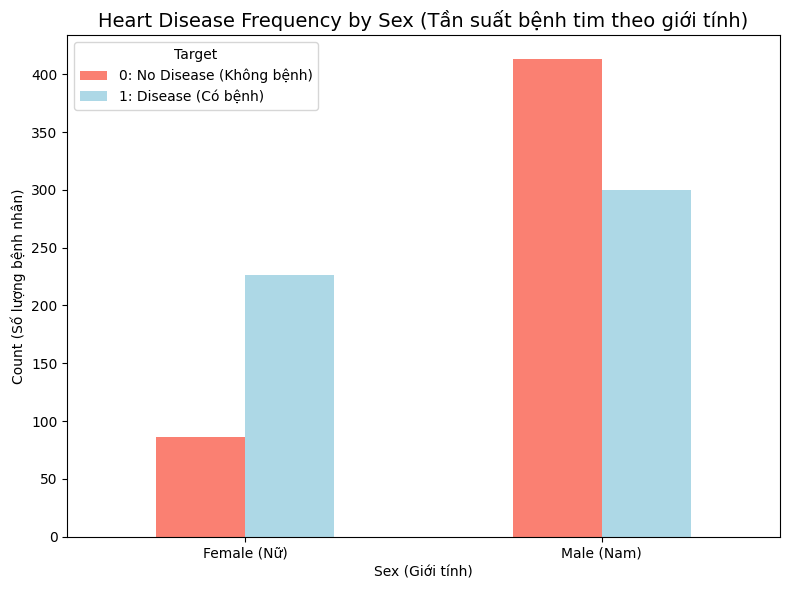

In [ ]:
crosstab_df = pd.crosstab(df['sex'], df['target'])

plt.figure(figsize=(8, 6))

crosstab_df.plot(
    kind='bar',
    color=['salmon', 'lightblue'],
    ax=plt.gca()
)

plt.xticks(
    ticks=[0, 1],
    labels=['Female (Nữ)', 'Male (Nam)'],
    rotation=0
)

plt.legend(
    title='Target',
    labels=['0: No Disease (Không bệnh)', '1: Disease (Có bệnh)']
)

plt.title('Heart Disease Frequency by Sex (Tần suất bệnh tim theo giới tính)', fontsize=14)
plt.xlabel('Sex (Giới tính)')
plt.ylabel('Count (Số lượng bệnh nhân)')
plt.tight_layout()
plt.show()

**Vẽ biểu đồ histogram cho cột 'age' trong DataFrame df**

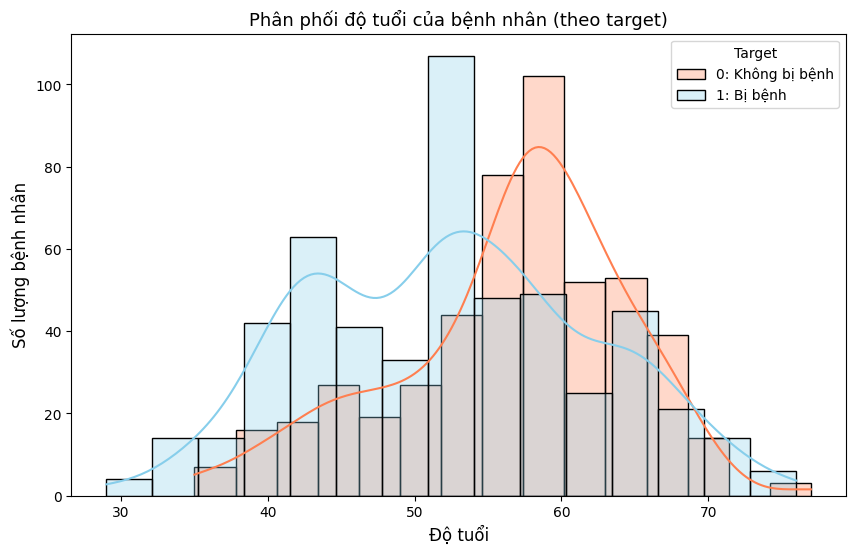

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Vẽ histogram + đường KDE cho mỗi nhóm target
sns.histplot(data=df[df['target'] == 0]['age'],
             bins=15, color='coral', kde=True, label='0: Không bị bệnh', alpha=0.3)

sns.histplot(data=df[df['target'] == 1]['age'],
             bins=15, color='skyblue', kde=True, label='1: Bị bệnh', alpha=0.3)

# Thêm tiêu đề và nhãn
plt.title('Phân phối độ tuổi của bệnh nhân (theo target)', fontsize=13)
plt.xlabel('Độ tuổi', fontsize=12)
plt.ylabel('Số lượng bệnh nhân', fontsize=12)
plt.legend(title='Target')

# Hiển thị biểu đồ
plt.show()

**Ma trận tương quan**

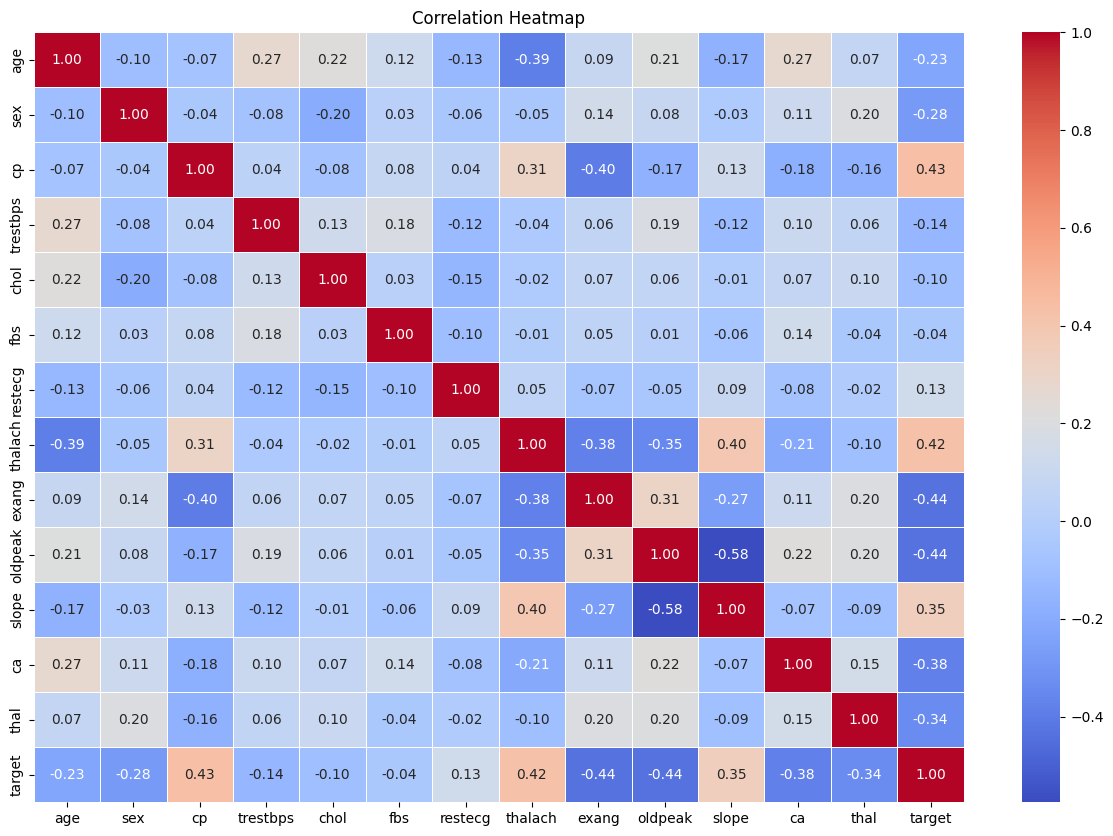

In [ ]:
# Tính ma trận tương quan giữa tất cả các biến trong df
corr_matrix = df.corr()
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

**Biểu đồ phân phối**

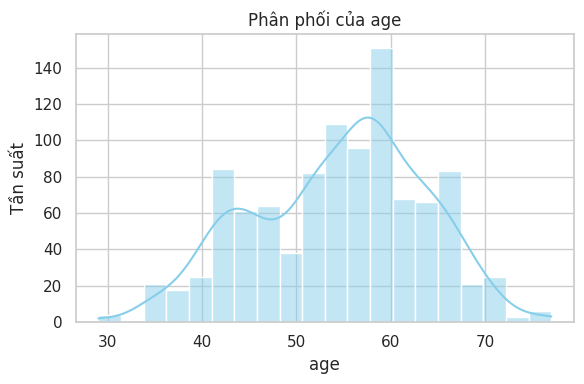

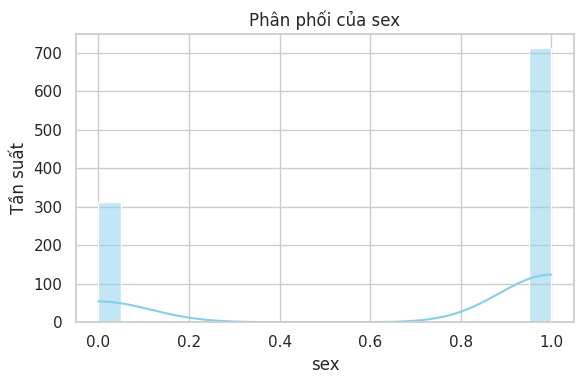

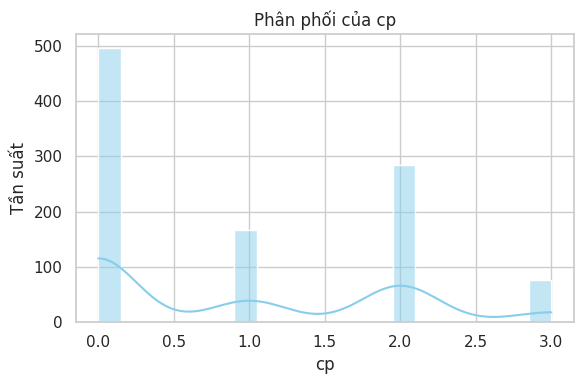

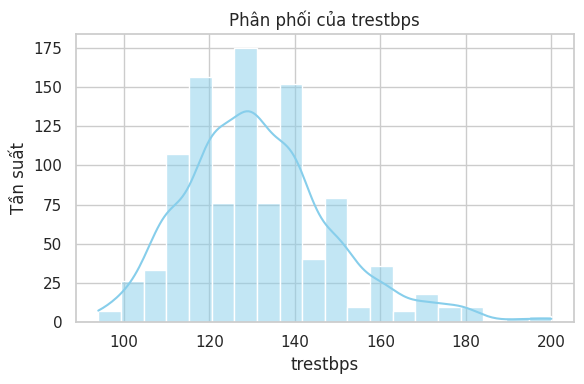

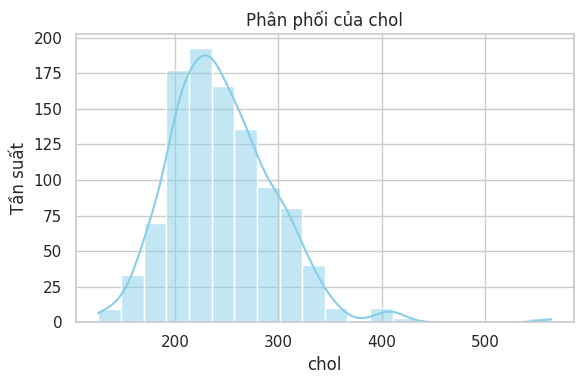

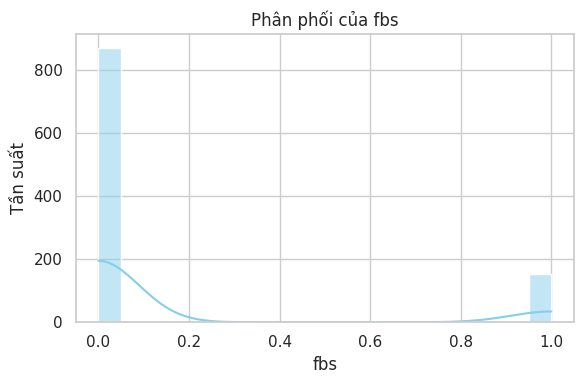

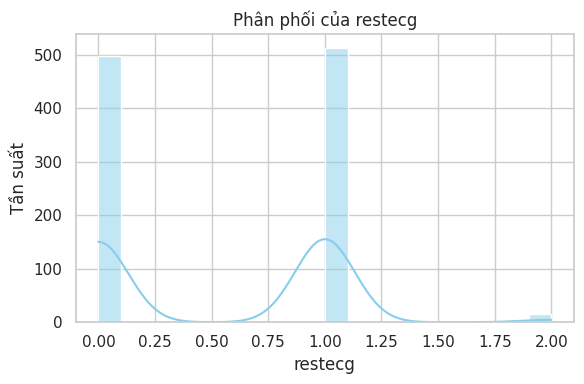

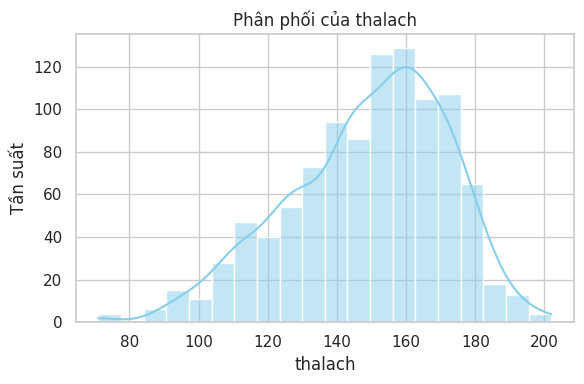

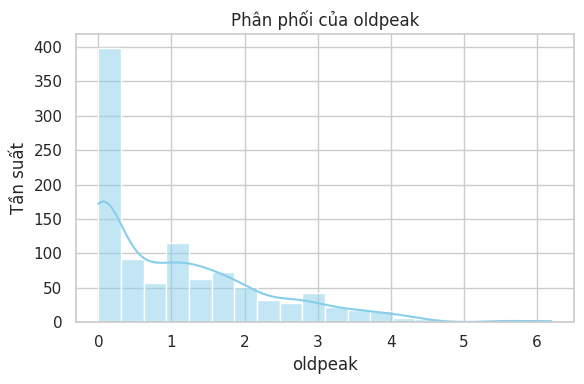

In [ ]:

# Chọn 9 biến đặc trưng
cols = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
        'restecg', 'thalach', 'oldpeak']

# Thiết lập style
sns.set(style="whitegrid")

# Vẽ histogram + KDE cho từng biến
for col in cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=20, color='skyblue')
    plt.title(f'Phân phối của {col}')
    plt.xlabel(col)
    plt.ylabel('Tần suất')
    plt.tight_layout()
    plt.show()


**Biểu đồ Boxlot**

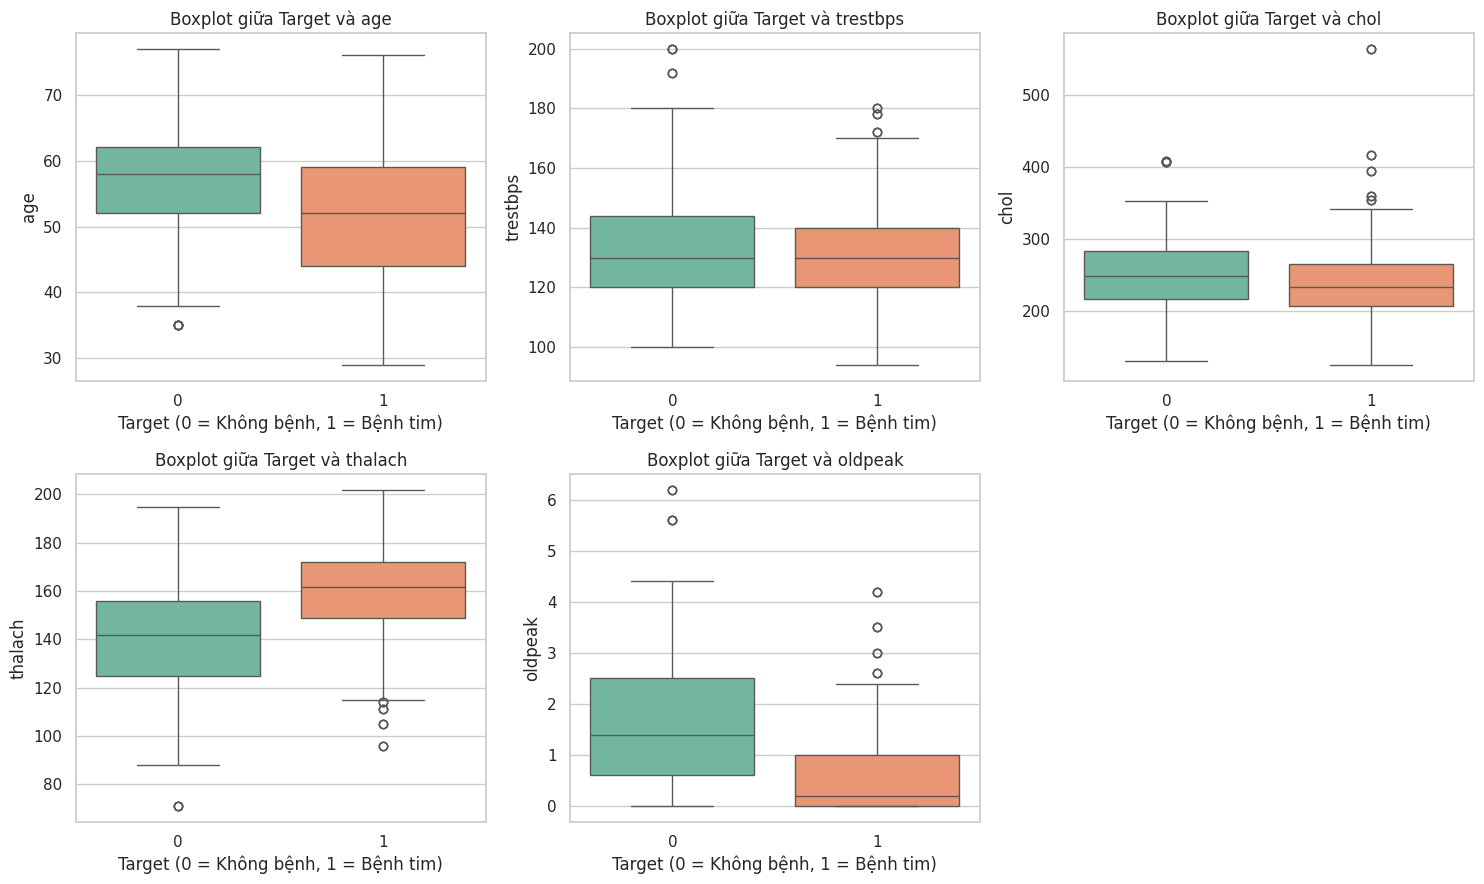

In [ ]:
sns.set(style="whitegrid")
features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for i, feature in enumerate(features):
    ax = axes[i // 3, i % 3]
    sns.boxplot(data=df, x="target", y=feature, hue="target", palette="Set2",legend=False, ax=ax)
    ax.set_title(f"Boxplot giữa Target và {feature}")
    ax.set_xlabel("Target (0 = Không bệnh, 1 = Bệnh tim)")
    ax.set_ylabel(feature)

axes[1, 2].axis("off")
plt.tight_layout()
plt.show()

**Import thư viện**

In [ ]:
# Các mô hình từ thư viện scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier


# Đánh giá mô hình
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

**Tải dữ liệu**

In [ ]:
data = pd.read_csv('heart.csv')

# Định nghĩa Features (X) và Target (Y)
X = data.drop(['target'], axis=1)
y = data['target']

# Chia tập huấn luyện và kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Chuẩn hóa dữ liệu (Scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


print("Thành công")
print(f"Kích thước tập huấn luyện: {X_train_scaled.shape}")
print(f"Kích thước tập kiểm tra: {X_test_scaled.shape}")


Thành công
Kích thước tập huấn luyện: (717, 13)
Kích thước tập kiểm tra: (308, 13)


**Thuật toán Logistic Regression**

Không dùng thư viện

In [ ]:
def sigmoid(z) :
    return 1 / (1 + np.exp(-z))


def predict_proba(X, weights):
    z = np.dot(X, weights)
    return sigmoid(z)


def logistic_regression_scratch(X, y, learning_rate=0.01, n_iterations=1000):
    n_samples, n_features = X.shape
    weights = np.zeros((n_features, 1))  # vector cột

    y = y.reshape(-1, 1)  # đảm bảo y là vector cột

    for _ in range(n_iterations):
        # Dự đoán
        y_hat = sigmoid(np.dot(X, weights))
        # Sai số
        error = y_hat - y
        # Gradient
        gradient = (1 / n_samples) * np.dot(X.T, error)
        # Cập nhật trọng số
        weights -= learning_rate * gradient

    return weights


X_train_ext = np.concatenate((np.ones((X_train_scaled.shape[0], 1)), X_train_scaled), axis=1)
X_test_ext  = np.concatenate((np.ones((X_test_scaled.shape[0], 1)), X_test_scaled), axis=1)

# Huấn luyện mô hình trên dữ liệu đã được Scale
W = logistic_regression_scratch(X_train_ext, y_train.values, learning_rate=0.01, n_iterations=1000)

# Dự đoán trên tập kiểm tra
y_prob = predict_proba(X_test_ext, W)

# Phân loại (ngưỡng 0.5)
y_pred = (y_prob >= 0.5).astype(int)


# Đánh giá
print("=== Logistic Regression không dùng thư viện ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")


=== Logistic Regression không dùng thư viện ===
Accuracy:  0.8214
Precision: 0.7877
Recall:    0.8924
F1-Score:  0.8368


Dùng thư viện

In [ ]:
# Khởi tạo mô hình (C=1.0 là tham số Regularization mặc định)
logreg_model = LogisticRegression(solver='liblinear', random_state=42)

# Huấn luyện mô hình trên dữ liệu đã được Scale
logreg_model.fit(X_train_scaled, y_train)

# Dự đoán trên tập kiểm tra
y_pred_sklearn = logreg_model.predict(X_test_scaled)

# Đánh giá
print("=== Logistic Regression (Scikit-learn) ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_sklearn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_sklearn):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_sklearn):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_sklearn):.4f}")

=== Logistic Regression (Scikit-learn) ===
Accuracy:  0.8182
Precision: 0.7833
Recall:    0.8924
F1-Score:  0.8343


**So sánh mô hình không sử dụng thư viện và sử dụng thư viện**

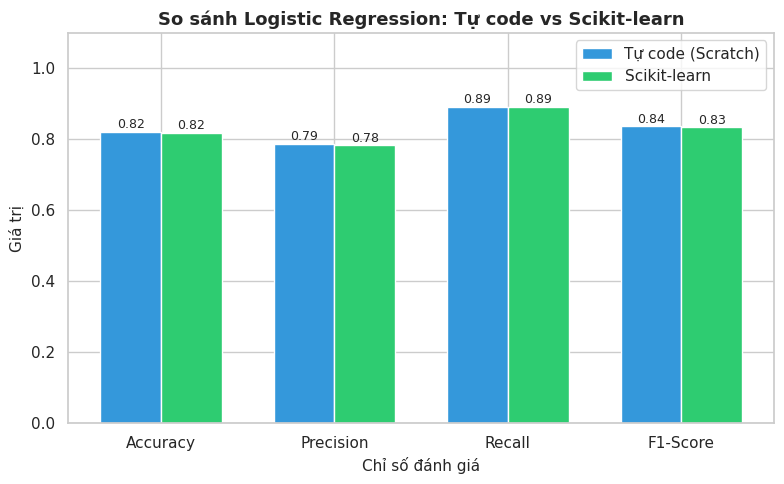

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Đánh giá mô hình (đảm bảo bạn đã có y_test, y_pred_sklearn, y_pred_scratch) ---
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

scratch_scores = [
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred)
]

sklearn_scores = [
    accuracy_score(y_test, y_pred_sklearn),
    precision_score(y_test, y_pred_sklearn),
    recall_score(y_test, y_pred_sklearn),
    f1_score(y_test, y_pred_sklearn)
]

# --- Vẽ biểu đồ so sánh ---
x = np.arange(len(metrics))
width = 0.35  # độ rộng của cột

plt.figure(figsize=(8, 5))
bars1 = plt.bar(x - width/2, scratch_scores, width, label='Tự code (Scratch)', color='#3498db')
bars2 = plt.bar(x + width/2, sklearn_scores, width, label='Scikit-learn', color='#2ecc71')

# Gán nhãn trên đầu cột
for bar in bars1 + bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01, f"{height:.2f}", ha='center', fontsize=9)

plt.xlabel('Chỉ số đánh giá', fontsize=11)
plt.ylabel('Giá trị', fontsize=11)
plt.title('So sánh Logistic Regression: Tự code vs Scikit-learn', fontsize=13, fontweight='bold')
plt.xticks(x, metrics)
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()


**Thuật toán K-Nearest Neighbors (KNN)**

Không dùng thư viện

In [ ]:
# Hàm tính khoảng cách Euclidean
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((point1 - point2)**2))



# Hàm dự đoán KNN cho 1 điểm
def knn_predict_point(x_new, X_train, y_train, k):
    distances = []

    # 1. Tính khoảng cách từ x_new đến MỌI điểm trong X_train
    for i in range(len(X_train)):
        dist = euclidean_distance(x_new, X_train[i])
        distances.append((dist, y_train.iloc[i])) # Lưu (khoảng cách, nhãn)

    # 2. Sắp xếp và chọn k láng giềng gần nhất
    distances.sort(key=lambda x: x[0])
    k_nearest = distances[:k]

    # 3. Lấy nhãn của k láng giềng
    k_labels = [label for (dist, label) in k_nearest]

    # 4. Bỏ phiếu đa số (Majority Vote) để đưa ra dự đoán
    from collections import Counter
    most_common = Counter(k_labels).most_common(1)
    return most_common[0][0]



# Hàm dự đoán KNN cho toàn bộ tập test
def knn_scratch(X_train, y_train, X_test, k=5):
    y_pred = [knn_predict_point(x_test_row, X_train, y_train, k) for x_test_row in X_test]
    return np.array(y_pred)

# Huấn luyện và dự đoán (Chọn K=5 là giá trị phổ biến)
K_value = 5
y_pred_knn_scratch = knn_scratch(X_train_scaled, y_train, X_test_scaled, k=K_value)

# Đánh giá
print(f"=== K-Nearest Neighbors (Tự code, K={K_value}) ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_knn_scratch):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn_scratch):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_knn_scratch):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_knn_scratch):.4f}")

=== K-Nearest Neighbors (Tự code, K=5) ===
Accuracy:  0.8669
Precision: 0.8874
Recall:    0.8481
F1-Score:  0.8673


Dùng thư viện

In [ ]:
# Chọn K=5
K_value = 5
knn_model = KNeighborsClassifier(n_neighbors=K_value)

# Huấn luyện
knn_model.fit(X_train_scaled, y_train)

# Dự đoán trên tập kiểm tra
y_pred_knn_sklearn = knn_model.predict(X_test_scaled)

# Đánh giá
print(f"=== K-Nearest Neighbors (Scikit-learn, K={K_value}) ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_knn_sklearn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn_sklearn):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_knn_sklearn):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_knn_sklearn):.4f}")

=== K-Nearest Neighbors (Scikit-learn, K=5) ===
Accuracy:  0.8669
Precision: 0.8874
Recall:    0.8481
F1-Score:  0.8673


**So sánh mô hình không sử dụng thư viện và sử dụng thư viện**

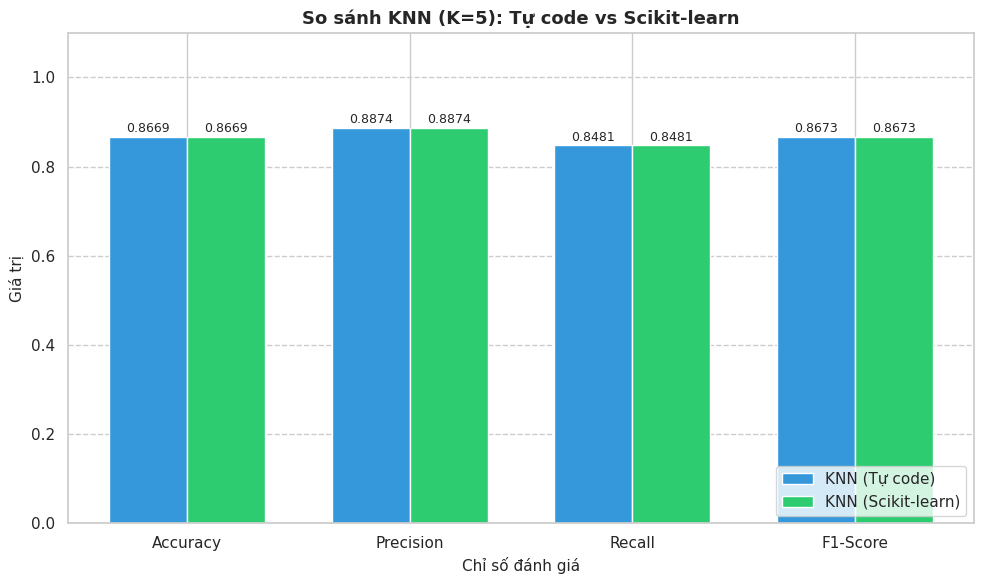

In [ ]:
# Cell mới: Biểu đồ so sánh KNN (Tự code vs Scikit-learn)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# --- 1. Tính toán Metrics cho cả hai phiên bản ---
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

# 1.1. Scores cho phiên bản Tự code (Scratch)
scratch_scores = [
    accuracy_score(y_test, y_pred_knn_scratch),
    precision_score(y_test, y_pred_knn_scratch),
    recall_score(y_test, y_pred_knn_scratch),
    f1_score(y_test, y_pred_knn_scratch)
]

# 1.2. Scores cho phiên bản Scikit-learn
sklearn_scores = [
    accuracy_score(y_test, y_pred_knn_sklearn),
    precision_score(y_test, y_pred_knn_sklearn),
    recall_score(y_test, y_pred_knn_sklearn),
    f1_score(y_test, y_pred_knn_sklearn)
]


# --- 2. Vẽ biểu đồ so sánh ---
x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))
bars1 = plt.bar(x - width/2, scratch_scores, width, label='KNN (Tự code)', color='#3498db')
bars2 = plt.bar(x + width/2, sklearn_scores, width, label='KNN (Scikit-learn)', color='#2ecc71')

# Gán nhãn giá trị (scores) trên đầu mỗi cột
for bar in bars1 + bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01, f"{height:.4f}", ha='center', fontsize=9)

plt.xlabel('Chỉ số đánh giá', fontsize=11)
plt.ylabel('Giá trị', fontsize=11)
plt.title(f'So sánh KNN (K={K_value}): Tự code vs Scikit-learn', fontsize=13, fontweight='bold')
plt.xticks(x, metrics)
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

**Setup data**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Tải Dữ liệu
data = pd.read_csv('heart.csv')

# Định nghĩa Features (X) và Target (Y)
X = data.drop(['target'], axis=1)
y = data['target']

# Chia tập huấn luyện và kiểm tra (30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

**Tối ưu tham số C**,
**sử dụng GridSearchCV với 5-Fold CV để tìm ra $C$ tối ưu.**

In [ ]:
# Pipeline sẽ tự động scale dữ liệu bên trong quá trình CV
logreg_pipe = make_pipeline(StandardScaler(),
                            LogisticRegression(solver='liblinear', random_state=42))

# Định nghĩa lưới tham số C
param_grid_logreg = {
    'logisticregression__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

# Chạy Grid Search CV (ưu tiên F1-score)
grid_search_logreg = GridSearchCV(
    logreg_pipe,
    param_grid_logreg,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

print("Bắt đầu chạy Grid Search cho Logistic Regression...")
grid_search_logreg.fit(X_train, y_train)

# Lấy kết quả tốt nhất
best_C_logreg = grid_search_logreg.best_params_['logisticregression__C']
best_f1_logreg_cv = grid_search_logreg.best_score_
best_logreg_model = grid_search_logreg.best_estimator_

print("=====================================================")
print(f"Logistic Regression: Tham số C tối ưu (CV F1-score): {best_C_logreg}")
print(f"Logistic Regression: F1-Score CV tốt nhất (5-Fold CV): {best_f1_logreg_cv:.4f}")
print("=====================================================")

Bắt đầu chạy Grid Search cho Logistic Regression...
Logistic Regression: Tham số C tối ưu (CV F1-score): 0.1
Logistic Regression: F1-Score CV tốt nhất (5-Fold CV): 0.8574


**Tối ưu tham số K, sử dụng GridSearchCV với 5-Fold CV để tìm ra $K$ tối ưu.**

In [ ]:
# Định nghĩa Pipeline (Scaling + Model)
knn_pipe = make_pipeline(StandardScaler(),
                         KNeighborsClassifier())

# Định nghĩa lưới tham số K (chọn số lẻ từ 1 đến 25)
k_range = list(range(1, 26, 2))
param_grid_knn = {
    'kneighborsclassifier__n_neighbors': k_range
}

# Chạy Grid Search CV (ưu tiên F1-score)
grid_search_knn = GridSearchCV(
    knn_pipe,
    param_grid_knn,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

print("\nBắt đầu chạy Grid Search cho KNN...")
grid_search_knn.fit(X_train, y_train)

# Lấy kết quả tốt nhất
best_K_knn = grid_search_knn.best_params_['kneighborsclassifier__n_neighbors']
best_f1_knn_cv = grid_search_knn.best_score_
best_knn_model = grid_search_knn.best_estimator_

print("=====================================================")
print(f"KNN: Tham số K tối ưu (CV F1-score): {best_K_knn}")
print(f"KNN: F1-Score trung bình (5-Fold CV): {best_f1_knn_cv:.4f}")
print("=====================================================")


Bắt đầu chạy Grid Search cho KNN...
KNN: Tham số K tối ưu (CV F1-score): 1
KNN: F1-Score trung bình (5-Fold CV): 0.9640


**Đánh giá cuối cùng trên tập Test**

In [ ]:
# Đánh giá cuối cùng trên TestSet
print("=== Đánh giá Cuối cùng trên Tập Test (Sử dụng tham số tối ưu) ===")

models = {
    f"LogReg (C={best_C_logreg})": best_logreg_model,
    f"KNN (K={best_K_knn})": best_knn_model
}

results_df = pd.DataFrame(columns=['Model', 'Accuracy', 'Recall', 'Precision', 'F1-Score'])

for name, model in models.items():
    # Dự đoán trên tập kiểm tra
    y_pred = model.predict(X_test)

    # Tính toán Metrics
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # In ra và thêm vào DataFrame
    print(f"\n--- {name} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Recall:   {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"F1-Score: {f1:.4f}")

    results_df.loc[len(results_df)] = [name, accuracy, recall, precision, f1]

# In bảng tổng hợp
print("\n" + "="*60)
print("BẢNG TỔNG HỢP KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST")
print("="*60)
print(results_df.to_markdown(index=False, floatfmt=".4f"))

=== Đánh giá Cuối cùng trên Tập Test (Sử dụng tham số tối ưu) ===

--- LogReg (C=0.1) ---
Accuracy: 0.8214
Recall:   0.8987
Precision: 0.7845
F1-Score: 0.8378

--- KNN (K=1) ---
Accuracy: 0.9903
Recall:   0.9810
Precision: 1.0000
F1-Score: 0.9904

BẢNG TỔNG HỢP KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST
| Model          |   Accuracy |   Recall |   Precision |   F1-Score |
|:---------------|-----------:|---------:|------------:|-----------:|
| LogReg (C=0.1) |     0.8214 |   0.8987 |      0.7845 |     0.8378 |
| KNN (K=1)      |     0.9903 |   0.9810 |      1.0000 |     0.9904 |


=== Đánh giá Cuối cùng trên Tập Test (Sử dụng tham số tối ưu) ===

--- LogReg (C=0.1) ---
Accuracy: 0.8214
Recall:   0.8987
Precision: 0.7845
F1-Score: 0.8378

--- KNN (K=1) ---
Accuracy: 0.9903
Recall:   0.9810
Precision: 1.0000
F1-Score: 0.9904

BẢNG TỔNG HỢP KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST
| Model          |   Accuracy |   Recall |   Precision |   F1-Score |
|:---------------|-----------:|---------:|------------:|-----------:|
| LogReg (C=0.1) |     0.8214 |   0.8987 |      0.7845 |     0.8378 |
| KNN (K=1)      |     0.9903 |   0.9810 |      1.0000 |     0.9904 |

--- VISUALIZE: CONFUSION MATRIX ---


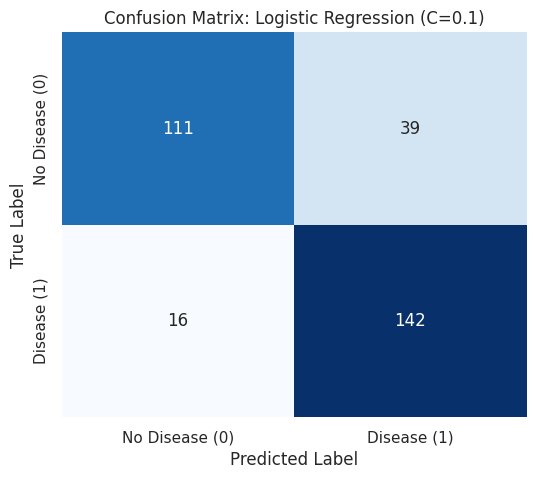

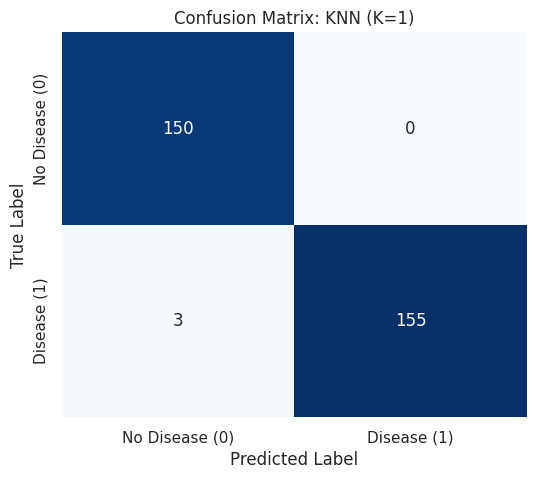


--- VISUALIZE: SO SÁNH METRICS ---


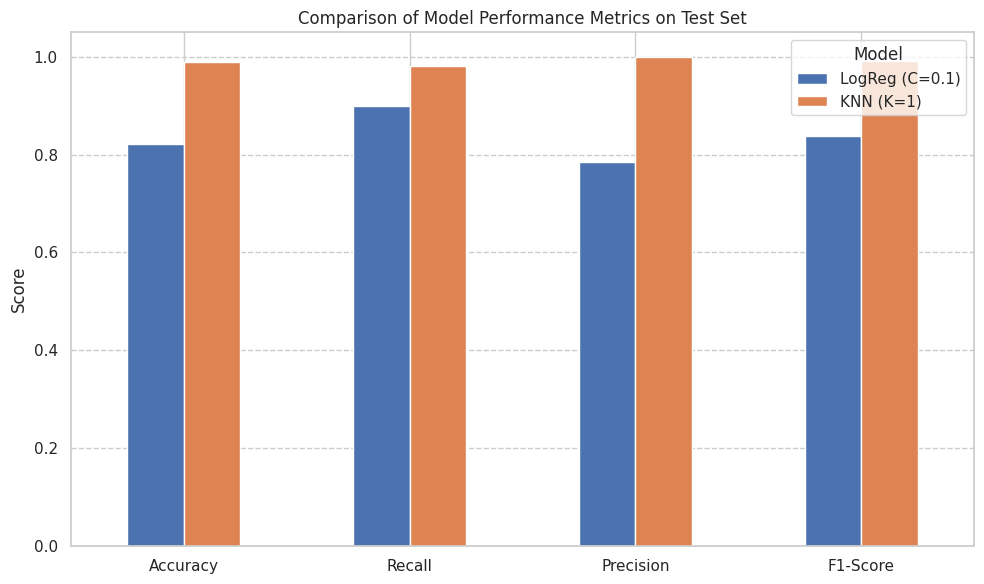

In [ ]:
# Đánh giá Cuối cùng trên Tập Test (Final Evaluation) và VISUALIZE

# --- HÀM HỖ TRỢ VISUALIZE ---
def plot_confusion_matrix(y_true, y_pred, title):
    """Vẽ và hiển thị Confusion Matrix"""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No Disease (0)', 'Disease (1)'],
                yticklabels=['No Disease (0)', 'Disease (1)'])
    plt.title(f'Confusion Matrix: {title}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

def plot_metrics_comparison(results_df):
    """Vẽ và hiển thị Bar Chart so sánh các Metrics"""
    metrics_data = results_df.set_index('Model').T
    plt.figure(figsize=(10, 6))

    # Vẽ biểu đồ Bar Chart
    metrics_data.plot(kind='bar', ax=plt.gca())

    plt.title('Comparison of Model Performance Metrics on Test Set')
    plt.ylabel('Score')
    plt.xticks(rotation=0)
    plt.legend(title='Model')
    plt.grid(axis='y', linestyle='--')
    plt.tight_layout()
    plt.show()

# --- BẮT ĐẦU ĐÁNH GIÁ ---
print("=== Đánh giá Cuối cùng trên Tập Test (Sử dụng tham số tối ưu) ===")

models = {
    f"LogReg (C={best_C_logreg})": best_logreg_model,
    f"KNN (K={best_K_knn})": best_knn_model
}

results_df = pd.DataFrame(columns=['Model', 'Accuracy', 'Recall', 'Precision', 'F1-Score'])

y_pred_logreg = None
y_pred_knn = None

for name, model in models.items():
    # Dự đoán trên tập kiểm tra
    y_pred = model.predict(X_test)

    # Lưu kết quả dự đoán để vẽ CM sau
    if "LogReg" in name:
        y_pred_logreg = y_pred
    else:
        y_pred_knn = y_pred

    # Tính toán Metrics
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # In ra và thêm vào DataFrame
    print(f"\n--- {name} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Recall:   {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"F1-Score: {f1:.4f}")

    results_df.loc[len(results_df)] = [name, accuracy, recall, precision, f1]

# In bảng tổng hợp
print("\n" + "="*60)
print("BẢNG TỔNG HỢP KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST")
print("="*60)
print(results_df.to_markdown(index=False, floatfmt=".4f"))


# --- VISUALIZE KẾT QUẢ ---

# 1. Confusion Matrix
print("\n--- VISUALIZE: CONFUSION MATRIX ---")
if y_pred_logreg is not None:
    plot_confusion_matrix(y_test, y_pred_logreg, f"Logistic Regression (C={best_C_logreg})")
if y_pred_knn is not None:
    plot_confusion_matrix(y_test, y_pred_knn, f"KNN (K={best_K_knn})")

# 2. Bar Chart so sánh Metrics
print("\n--- VISUALIZE: SO SÁNH METRICS ---")
plot_metrics_comparison(results_df)